
# Decoding square root encoded data

Data downlinked from the individual PUNCH spacecraft are usually square root encoded. This decoding is completed as part of the regular data processing pipeline for end-user data products. If using Level 0 manually, you may want to decode this data manually, as outlined here.


In [1]:
%%capture
%pip install punchbowl

Data downlinked from the individual PUNCH spacecraft are usually square root encoded. This decoding is completed as part of the regular data processing pipeline for end-user data products. If using Level 0 manually, you may want to decode this data manually, as outlined here.



Load libraries



In [2]:
from sunpy.map import Map
from sunpy.net import Fido
from sunpy.net import attrs as a

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from punchbowl.data import load_ndcube_from_fits
from punchbowl.data.visualize import cmap_punch
from punchbowl.level1.sqrt import decode_sqrt

In [3]:
time_range = a.Time('2025/06/01 00:00:00', '2025/06/01 00:02:00')
result = Fido.search(time_range, a.Instrument('WFI-2'))

files = Fido.fetch(result[0][0])

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

PUNCH_L0_CR2_20250601000029_v0a.fits:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

We can begin by loading sample data into an NDCube object.



In [4]:
cube = load_ndcube_from_fits(files[0])

Note that for level 0 data the data is still square-root encoded, and will be unpacked in subsequent levels. You can manually decoded this data with the same pipeline function.



In [5]:
data_decoded = decode_sqrt(cube.data)

Now that we have this data square-root decoded, we can plot the image.



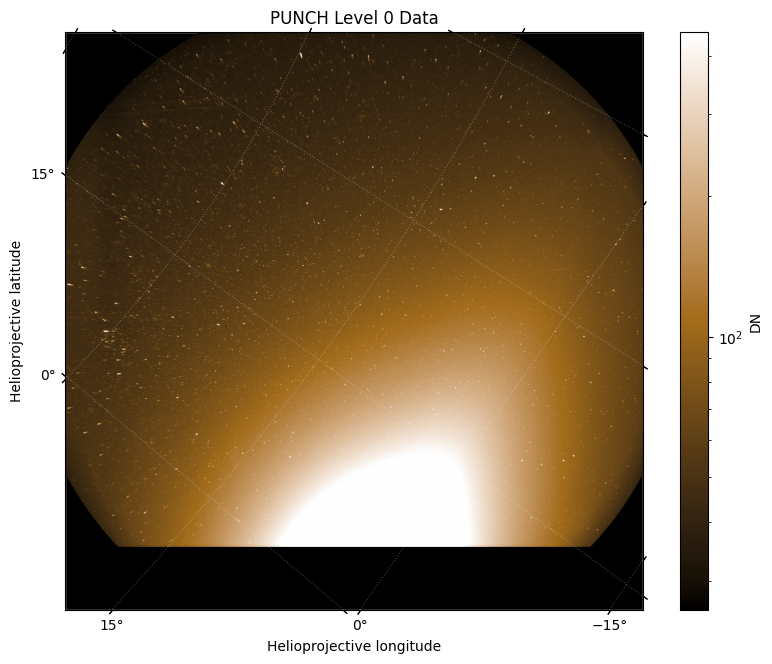

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={"projection":cube.wcs})

im = ax.imshow(data_decoded, cmap=cmap_punch, norm=LogNorm(vmax=450))

lon, lat = ax.coords
lat.set_major_formatter("dd")
lon.set_major_formatter("dd")
ax.set_facecolor("black")
ax.coords.grid(color="white", alpha=.25, ls="dotted")
ax.set_xlabel("Helioprojective longitude")
ax.set_ylabel("Helioprojective latitude")
ax.set_title("PUNCH Level 0 Data")
fig.colorbar(im, ax=ax, label="DN")
plt.show()